In [1]:
import pandas as pd
import scanpy as sc
import numpy as np
import scipy.sparse as sp
import os
from datetime import datetime

def checkpoint(msg):
    print(f"[{datetime.now().strftime('%Y-%m-%d %H:%M:%S')}] {msg}", flush=True)


In [2]:
genes_df = pd.read_csv("/net/bq-storage/ag-cherrmann/bq_cinac/projects/synimmune/results/04_NMF_GSEAonHGNC/04_3_nmf_all_gsea_c7/genes.csv")
hiha_adata = sc.read_h5ad("/net/bq-storage/ag-cherrmann/bq_cinac/projects/synimmune/data/03_HIHAtlas/HIHAtlas_ds_TICAannot.h5ad")


### 1 - rebuild log-normalized .X from raw counts

In [8]:
# match on feature_name (HGNC symbol) instead of the mixed-format index
current_feature_names = hiha_adata.var['feature_name'].astype(str)
raw_feature_names = hiha_adata.raw.var['feature_name'].astype(str)

common_names = set(current_feature_names) & set(raw_feature_names)
print(f"{len(common_names)} / {len(current_feature_names)} current genes matched via feature_name")

31007 / 32338 current genes matched via feature_name


In [9]:
print("Duplicates in current var feature_name:", hiha_adata.var['feature_name'].duplicated().sum())
print("Duplicates in raw var feature_name:", hiha_adata.raw.var['feature_name'].duplicated().sum())

Duplicates in current var feature_name: 0
Duplicates in raw var feature_name: 12


In [10]:
# build a raw AnnData with feature_name as the index for easy subsetting
raw_adata = hiha_adata.raw.to_adata()
raw_adata.var['ensembl_id'] = raw_adata.var_names  # preserve original index just in case
raw_adata.var_names = raw_adata.var['feature_name'].astype(str)
raw_adata.var_names_make_unique()  # safety net, in case duplicates exist

# keep only genes present in current hiha_adata (via feature_name)
current_names = hiha_adata.var['feature_name'].astype(str)
common_names = current_names[current_names.isin(raw_adata.var_names)]

print(f"{len(common_names)} / {hiha_adata.n_vars} genes will be kept")

# subset BOTH objects to this common gene set, in the same order
hiha_adata = hiha_adata[:, current_names.isin(raw_adata.var_names)].copy()
raw_subset = raw_adata[:, hiha_adata.var['feature_name'].astype(str)].X.copy()

print(raw_subset.shape, hiha_adata.shape)  # should now match exactly

31007 / 32338 genes will be kept
(129435, 31007) (129435, 31007)


In [11]:
hiha_adata.layers['counts'] = raw_subset
hiha_adata.X = raw_subset.copy()

sc.pp.normalize_total(hiha_adata, target_sum=1e4)
sc.pp.log1p(hiha_adata)
hiha_adata.layers['lognorm'] = hiha_adata.X.copy()

print("X max after log1p:", hiha_adata.X.max())

X max after log1p: 9.039427


### 2 - overlap test 

In [3]:
overlap_records = []
for mp in genes_df["mp"].unique():
    mp_genes = genes_df.loc[genes_df["mp"] == mp, "gene"].tolist()
    n_total = len(mp_genes)
    n_present = sum(g in hiha_adata.var_names for g in mp_genes)
    overlap_records.append({
        "mp": mp,
        "n_total_genes": n_total,
        "n_present_genes": n_present,
        "pct_overlap": n_present / n_total if n_total > 0 else 0.0,
    })

overlap_df = pd.DataFrame(overlap_records).sort_values("pct_overlap")
print(overlap_df.to_string(index=False))

# flag MPs below a minimum overlap threshold
min_overlap = 0.5  # adjust as needed
low_overlap_mps = overlap_df.loc[overlap_df["pct_overlap"] < min_overlap, "mp"].tolist()
print(f"\n{len(low_overlap_mps)} / {len(overlap_df)} MPs below {min_overlap:.0%} gene overlap:")
print(low_overlap_mps)

  mp  n_total_genes  n_present_genes  pct_overlap
MP24             43               38     0.883721
 MP4             13               12     0.923077
 MP9             26               25     0.961538
 MP7             28               27     0.964286
 MP8             30               29     0.966667
MP26           9851             9747     0.989443
MP15            222              220     0.990991
MP17            798              794     0.994987
MP23            571              569     0.996497
 MP6             60               60     1.000000
MP11             94               94     1.000000
MP10              2                2     1.000000
 MP5              8                8     1.000000
 MP2             41               41     1.000000
 MP3              6                6     1.000000
 MP1             55               55     1.000000
MP16              9                9     1.000000
MP14             71               71     1.000000
MP13              2                2     1.000000


### 3 - scoring MPs of GBmap to Healthy immune cells

In [5]:
mps_to_score = overlap_df.loc[overlap_df["pct_overlap"] >= min_overlap, "mp"].tolist()

for mp in mps_to_score:
    mp_df = genes_df[genes_df["mp"] == mp]
    gene_weights = dict(zip(mp_df["gene"], mp_df["score"]))

    genes_present = [g for g in gene_weights if g in hiha_adata.var_names]
    weights = np.array([gene_weights[g] for g in genes_present])
    gene_idx = [hiha_adata.var_names.get_loc(g) for g in genes_present]

    X_sub = hiha_adata[:, gene_idx].X
    if sp.issparse(X_sub):
        X_sub = X_sub.toarray()

    weighted_score = (X_sub * weights).sum(axis=1) / weights.sum()
    hiha_adata.obs[f"{mp}_score"] = np.asarray(weighted_score).flatten()

print(f"Scored {len(mps_to_score)} MPs onto HIHAtlas.")

Scored 30 MPs onto HIHAtlas.


In [6]:
# MP-Score Spalten umbenennen: MP*_score → MP*_gbmap_score

# Alle MP-Score Spalten finden
mp_score_cols = [col for col in hiha_adata.obs.columns if col.startswith("MP") and col.endswith("_score")]

checkpoint(f"Found {len(mp_score_cols)} MP score columns: {mp_score_cols}")

# Umbenennen
for col in mp_score_cols:
    new_col = col.replace("_score", "_gbmap_score")
    hiha_adata.obs[new_col] = hiha_adata.obs[col]
    del hiha_adata.obs[col]
    checkpoint(f"Renamed: {col} → {new_col}")

# Check
mp_cols_new = [col for col in hiha_adata.obs.columns if "gbmap" in col]
checkpoint(f"New MP columns ({len(mp_cols_new)}): {mp_cols_new}")

[2026-08-28 13:16:30] Found 30 MP score columns: ['MP24_score', 'MP4_score', 'MP9_score', 'MP7_score', 'MP8_score', 'MP26_score', 'MP15_score', 'MP17_score', 'MP23_score', 'MP6_score', 'MP11_score', 'MP10_score', 'MP5_score', 'MP2_score', 'MP3_score', 'MP1_score', 'MP16_score', 'MP14_score', 'MP13_score', 'MP12_score', 'MP20_score', 'MP19_score', 'MP22_score', 'MP18_score', 'MP21_score', 'MP25_score', 'MP27_score', 'MP28_score', 'MP29_score', 'MP30_score']
[2026-08-28 13:16:30] Renamed: MP24_score → MP24_gbmap_score
[2026-08-28 13:16:30] Renamed: MP4_score → MP4_gbmap_score
[2026-08-28 13:16:30] Renamed: MP9_score → MP9_gbmap_score
[2026-08-28 13:16:30] Renamed: MP7_score → MP7_gbmap_score
[2026-08-28 13:16:30] Renamed: MP8_score → MP8_gbmap_score
[2026-08-28 13:16:30] Renamed: MP26_score → MP26_gbmap_score
[2026-08-28 13:16:30] Renamed: MP15_score → MP15_gbmap_score
[2026-08-28 13:16:30] Renamed: MP17_score → MP17_gbmap_score
[2026-08-28 13:16:30] Renamed: MP23_score → MP23_gbmap_scor

In [7]:
# Welche MP-Scores sind vorhanden?
mp_cols = [col for col in hiha_adata.obs.columns if "MP" in col and "score" in col]
print("MP score columns:", mp_cols)

# Was ist in obsm?
print("obsm keys:", hiha_adata.obsm.keys())

MP score columns: ['MP24_gbmap_score', 'MP4_gbmap_score', 'MP9_gbmap_score', 'MP7_gbmap_score', 'MP8_gbmap_score', 'MP26_gbmap_score', 'MP15_gbmap_score', 'MP17_gbmap_score', 'MP23_gbmap_score', 'MP6_gbmap_score', 'MP11_gbmap_score', 'MP10_gbmap_score', 'MP5_gbmap_score', 'MP2_gbmap_score', 'MP3_gbmap_score', 'MP1_gbmap_score', 'MP16_gbmap_score', 'MP14_gbmap_score', 'MP13_gbmap_score', 'MP12_gbmap_score', 'MP20_gbmap_score', 'MP19_gbmap_score', 'MP22_gbmap_score', 'MP18_gbmap_score', 'MP21_gbmap_score', 'MP25_gbmap_score', 'MP27_gbmap_score', 'MP28_gbmap_score', 'MP29_gbmap_score', 'MP30_gbmap_score']
obsm keys: KeysView(AxisArrays with keys: X_pca, X_pca_harmony, X_umap, level1_padj_wsum, level1_score_wsum, level2_padj_wsum, level2_score_wsum)


### 4 - UMAP grid: per MP score of GBmap

In [8]:
import re
import matplotlib.pyplot as plt

In [9]:

BASE = "/net/bq-storage/ag-cherrmann/bq_cinac/projects/synimmune"
OUT_DIR = f"{BASE}/results/09_HIHAtlas"
os.makedirs(OUT_DIR, exist_ok=True)

In [10]:
SELECTED_MPS = ["MP1", "MP2", "MP7", "MP8", "MP9", "MP11", "MP14", "MP15", "MP19", "MP20"]


In [11]:
# ── MP Score columns
mp_score_cols = [f"{i}_gbmap_score" for i in SELECTED_MPS]  # HERE MUST BE SELECTED MPS

# Check which MPs are available
checkpoint("Checking MP score columns:")
for mp in mp_score_cols:
    if mp in hiha_adata.obs.columns:
        n_nan = hiha_adata.obs[mp].isna().sum()
        checkpoint(f"✓ {mp}: {hiha_adata.obs[mp].nunique()} unique values, {n_nan} NaN")
    else:
        checkpoint(f"✗ {mp}: NOT FOUND")

# Verfügbare MPs filtern
available_mps = [mp for mp in mp_score_cols if mp in hiha_adata.obs.columns and hiha_adata.obs[mp].notna().any()]
checkpoint(f"\nAvailable MPs: {len(available_mps)}")
checkpoint(f"Available: {available_mps}")


[2026-08-28 13:16:39] Checking MP score columns:
[2026-08-28 13:16:39] ✓ MP1_gbmap_score: 109128 unique values, 0 NaN
[2026-08-28 13:16:39] ✓ MP2_gbmap_score: 120656 unique values, 0 NaN
[2026-08-28 13:16:39] ✓ MP7_gbmap_score: 28073 unique values, 0 NaN
[2026-08-28 13:16:39] ✓ MP8_gbmap_score: 34819 unique values, 0 NaN
[2026-08-28 13:16:39] ✓ MP9_gbmap_score: 43416 unique values, 0 NaN
[2026-08-28 13:16:39] ✓ MP11_gbmap_score: 71095 unique values, 0 NaN
[2026-08-28 13:16:39] ✓ MP14_gbmap_score: 92482 unique values, 0 NaN
[2026-08-28 13:16:39] ✓ MP15_gbmap_score: 129398 unique values, 0 NaN
[2026-08-28 13:16:39] ✓ MP19_gbmap_score: 68893 unique values, 0 NaN
[2026-08-28 13:16:39] ✓ MP20_gbmap_score: 69886 unique values, 0 NaN
[2026-08-28 13:16:39] 
Available MPs: 10
[2026-08-28 13:16:39] Available: ['MP1_gbmap_score', 'MP2_gbmap_score', 'MP7_gbmap_score', 'MP8_gbmap_score', 'MP9_gbmap_score', 'MP11_gbmap_score', 'MP14_gbmap_score', 'MP15_gbmap_score', 'MP19_gbmap_score', 'MP20_gbmap_s

In [12]:
MP_PALETTE = {
    "MP1_gbmap_score":  "#ff006e", 
    "MP2_gbmap_score":  "#8338ec", 
    "MP7_gbmap_score":  "#c9184a", 
    "MP8_gbmap_score":  "#fb8500",
    "MP9_gbmap_score":  "#ffb703", 
    "MP11_gbmap_score": "#d00000", 
    "MP14_gbmap_score": "#9d4edd", 
    "MP15_gbmap_score": "#ff4d6d",
    "MP19_gbmap_score": "#f77f00", 
    "MP20_gbmap_score": "#ffd60a",
}

palette = [MP_PALETTE[mp] for mp in available_mps]


[2026-08-28 13:18:55] Plotting UMAPs


[2026-08-28 13:18:55] Plotted MP1_gbmap_score
[2026-08-28 13:18:55] Plotted MP2_gbmap_score
[2026-08-28 13:18:55] Plotted MP7_gbmap_score
[2026-08-28 13:18:56] Plotted MP8_gbmap_score
[2026-08-28 13:18:56] Plotted MP9_gbmap_score
[2026-08-28 13:18:56] Plotted MP11_gbmap_score
[2026-08-28 13:18:56] Plotted MP14_gbmap_score
[2026-08-28 13:18:56] Plotted MP15_gbmap_score
[2026-08-28 13:18:56] Plotted MP19_gbmap_score
[2026-08-28 13:18:56] Plotted MP20_gbmap_score


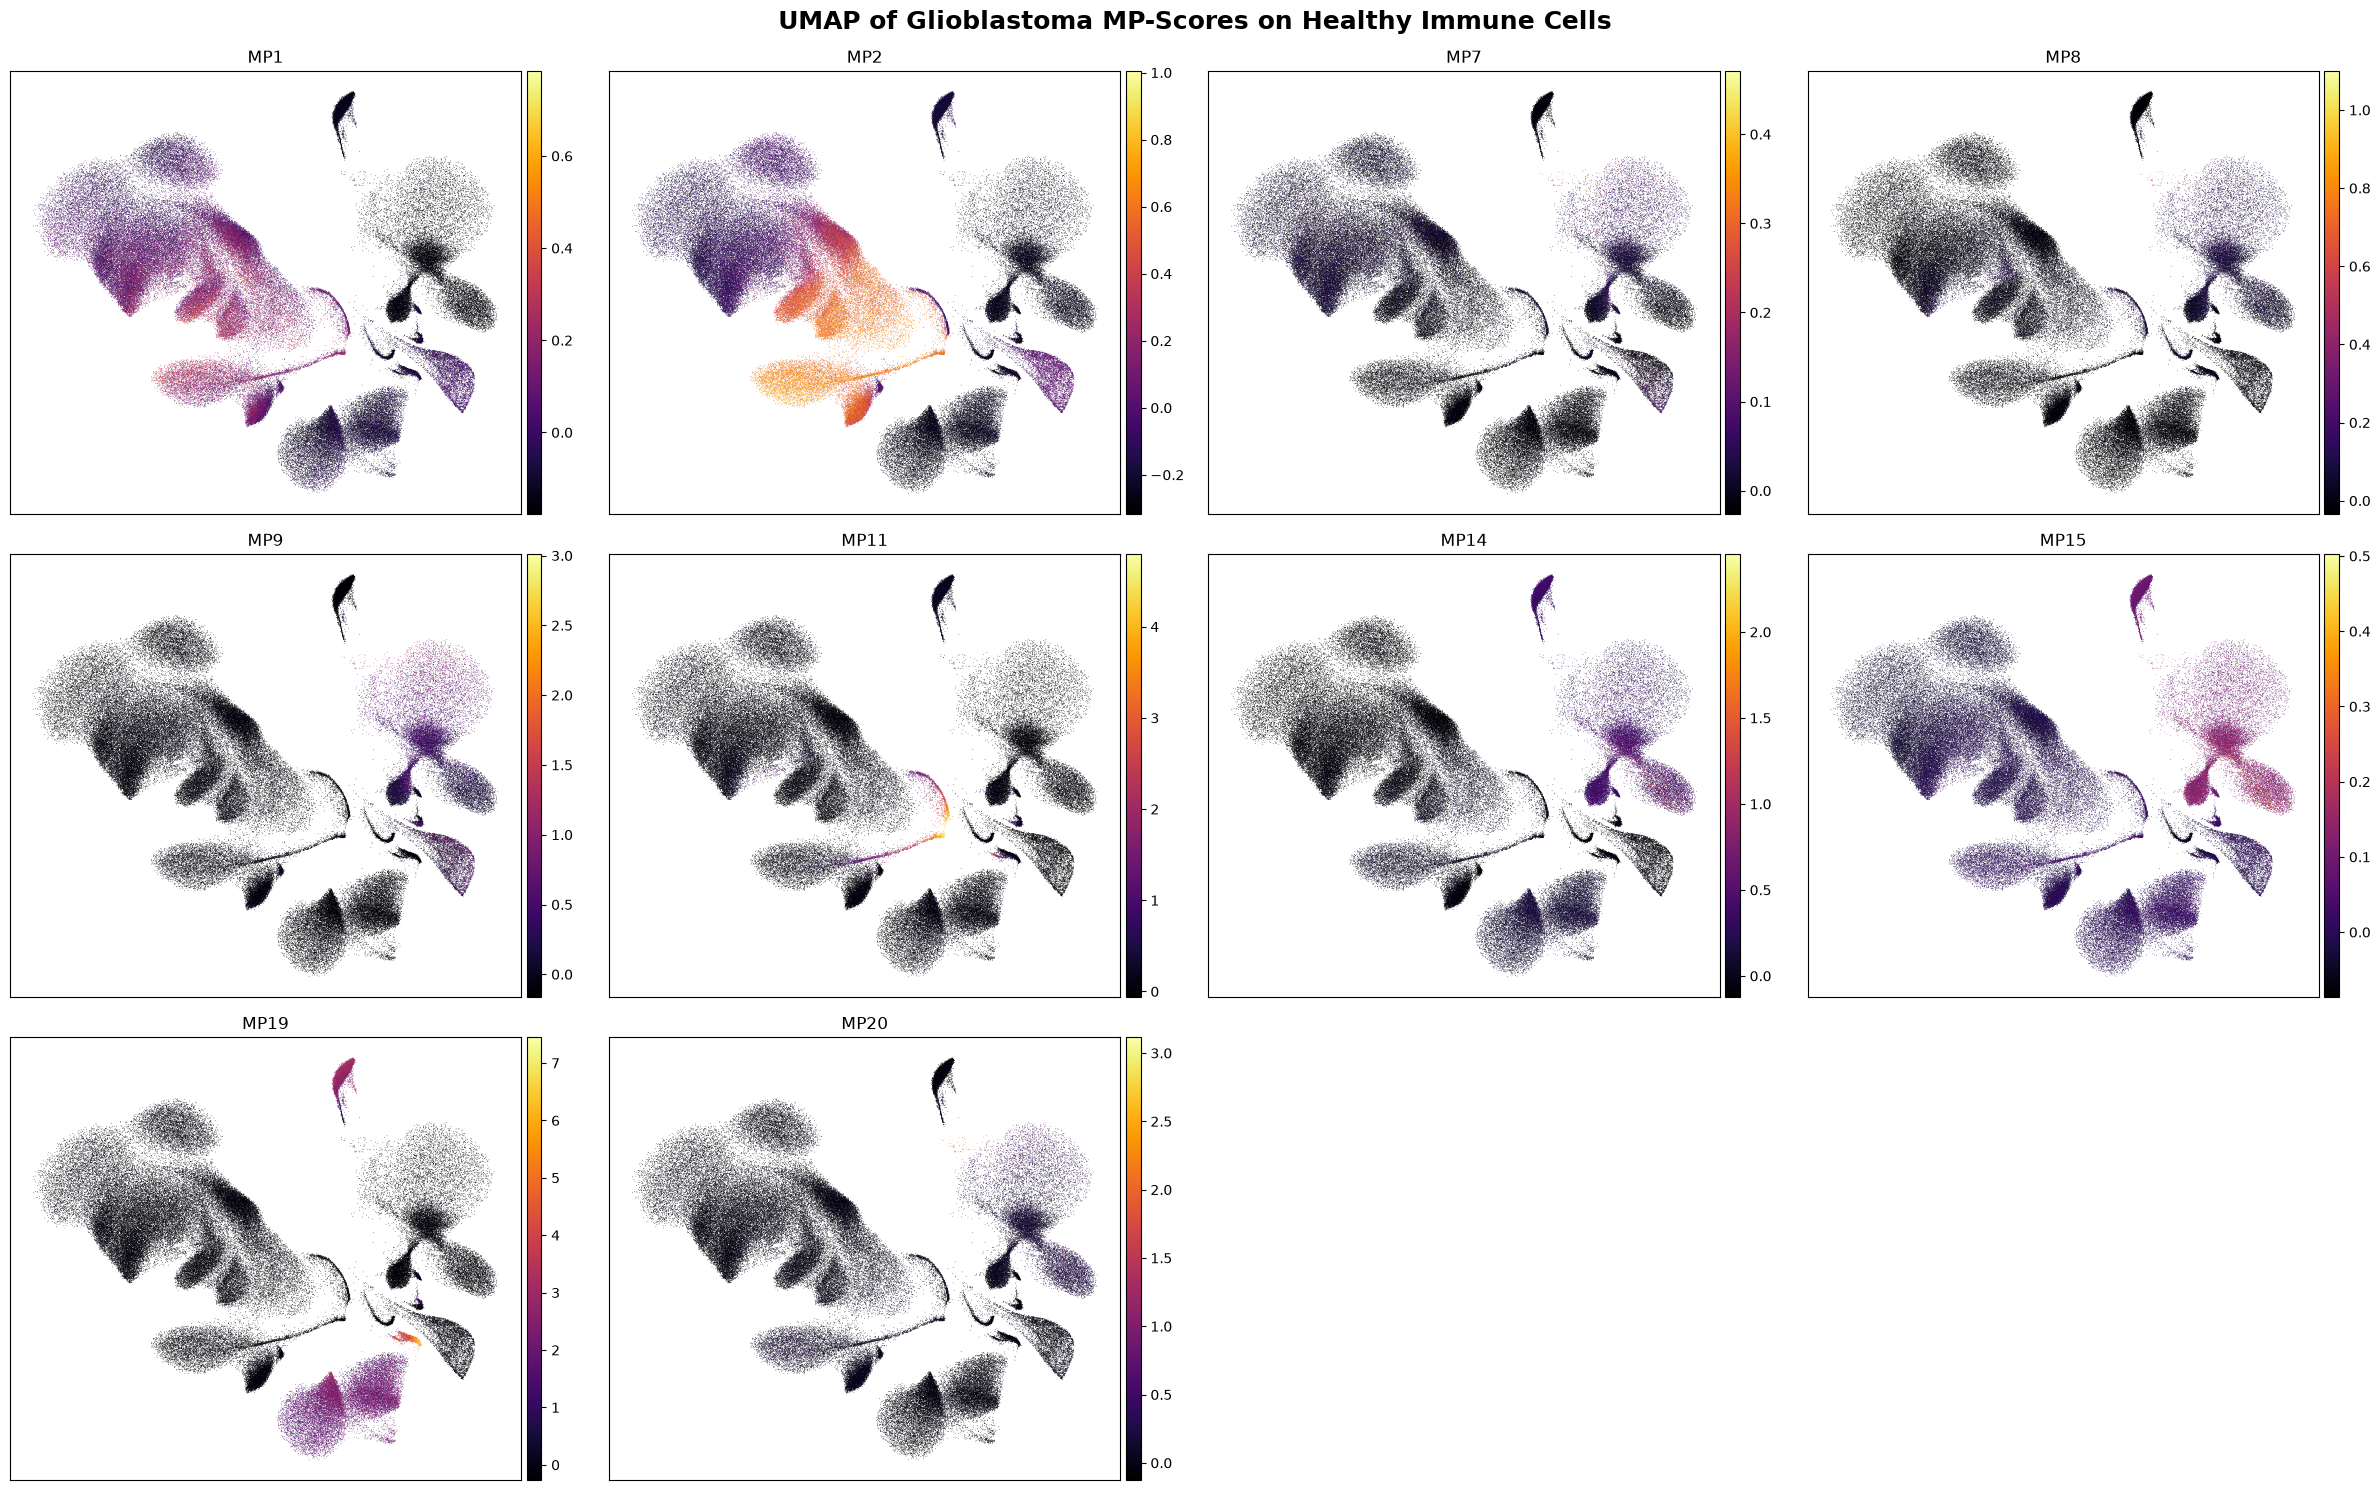

[2026-08-28 13:19:12] PDF saved


In [15]:


def mp_sort_key(name):
    m = re.search(r"(\d+)", name)
    return int(m.group(1)) if m else 0


ALL_MPS = sorted(available_mps, key=mp_sort_key)



checkpoint("Plotting UMAPs")
n_cols = 4  
n_rows = -(-len(ALL_MPS) // n_cols)  # ceiling division = 2


fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 6, n_rows * 5))  # ← figsize anpassen!
axes = axes.flatten()

fig.suptitle("UMAP of Glioblastoma MP-Scores on Healthy Immune Cells", fontsize=18, fontweight='bold', y=0.99)

for i, mp in enumerate(ALL_MPS):
    if mp in hiha_adata.obs.columns:
        # vmin/vmax per MP
        mp_vmin = hiha_adata.obs[mp].min()
        mp_vmax = hiha_adata.obs[mp].max()
        sc.pl.umap(
            hiha_adata, 
            color=mp, 
            color_map="inferno", 
            show=False, 
            ax=axes[i], 
            title=mp.replace("_gbmap_score", ""),
            vmin=mp_vmin,
            vmax=mp_vmax
        )
        axes[i].set_rasterized(True)
        axes[i].set_xlabel("")
        axes[i].set_ylabel("")
        axes[i].set_xticks([])
        axes[i].set_yticks([])
        checkpoint(f"Plotted {mp}")
    else:
        checkpoint(f"SKIPPED {mp} (not in adata.obs)")

for j in range(len(ALL_MPS), len(axes)):
    axes[j].set_visible(False)


plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "09_06a_umap_grid_GBscore_on_healthy.pdf"), bbox_inches="tight", dpi=300)
plt.show()
plt.close()
checkpoint("PDF saved")